# Gate Model — 20 Biomechanically Motivated Features + RFE Selection

**Design rationale:**  
We start with 20 features  
selected on biomechanical grounds — they directly capture the physical signature  
of a fall impact (sudden acceleration spike, rotational burst, post-fall stillness).  
RFE then reduces this to the minimal subset (target: 5–13 features) that meets  
the sensitivity constraint, keeping on-device computation genuinely lightweight.

- Group 1 (per-axis stats): accel_x/y/z max, std, peak2peak — plus accel_y mean jerk
- Group 2 (cross-axis magnitude): accel_magnitude_sq_mean, gyro_magnitude_sq_mean, accel_signal_magnitude_area, gyro_signal_magnitude_area
- Group 3 (SVM/3D composite): accel_svm_rms, accel_3d_peak2peak, accel_3d_std
- Group 4 (SVM/gyro magnitude): accel_svm_max, accel_svm_std, gyro_magnitude_std

**Pipeline:**
1. Load dataset — inspect shape and columns
2. Extract 20 features per window
3. Scaler comparison — No Scaling + 6 scalers × 6 models
4. Apply best scaler
5. RFE ranking + K sweep (K=5→15) → select minimal K
6. Hyperparameter tuning (C, penalty)
7. Threshold sweep on validation set
8. Final evaluation on test set

**Primary metric:** Sensitivity (TPR) — missing a fall is safety-critical  
**Constraint:** TPR ≥ 0.99 on validation before touching test set

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Dataset

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

DATASET_PATH = "/content/drive/MyDrive/SisFall_dataset/dataset_exp4_v4_final.npz"

data = np.load(DATASET_PATH, allow_pickle=True)

X_train_raw = data["X_train"]
y_train     = data["y_train"]
X_val_raw   = data["X_val"]
y_val       = data["y_val"]
X_test_raw  = data["X_test"]
y_test      = data["y_test"]

print("=" * 55)
print("DATASET LOADED")
print("=" * 55)
print(f"X_train_raw shape : {X_train_raw.shape}")
print(f"X_val_raw   shape : {X_val_raw.shape}")
print(f"X_test_raw  shape : {X_test_raw.shape}")
print()

if X_train_raw.ndim == 3:
    n_windows, n_timesteps, n_channels = X_train_raw.shape
    print(f"Format     : 3D raw windows")
    print(f"Timesteps  : {n_timesteps}")
    print(f"Channels   : {n_channels}  (expected 6: accel_x/y/z + gyro_x/y/z)")
    print("           ✓ Correct" if n_channels == 6 else f"           ⚠ Got {n_channels} channels")
elif X_train_raw.ndim == 2:
    print(f"Format     : 2D — {X_train_raw.shape[1]} values per window")

print()
print(f"Train : {len(y_train):,} windows | Fall %: {100*np.mean(y_train):.2f}")
print(f"Val   : {len(y_val):,} windows   | Fall %: {100*np.mean(y_val):.2f}")
print(f"Test  : {len(y_test):,} windows  | Fall %: {100*np.mean(y_test):.2f}")

DATASET LOADED
X_train_raw shape : (11303, 50, 6)
X_val_raw   shape : (2417, 50, 6)
X_test_raw  shape : (2317, 50, 6)

Format     : 3D raw windows
Timesteps  : 50
Channels   : 6  (expected 6: accel_x/y/z + gyro_x/y/z)
           ✓ Correct

Train : 11,303 windows | Fall %: 10.98
Val   : 2,417 windows   | Fall %: 10.96
Test  : 2,317 windows  | Fall %: 11.61


## 2. Feature Extraction — 20 Biomechanically Motivated Features

These 20 features are drawn from the same 4 groups used in the full feature set,  
selected based on which properties most directly capture fall impact physics:

| # | Feature | Group | Why it captures falls |
|---|---------|-------|----------------------|
| 1 | accel_x_max | G1 | Peak forward acceleration at impact |
| 2 | accel_y_max | G1 | Peak vertical acceleration at impact |
| 3 | accel_z_max | G1 | Peak lateral acceleration at impact |
| 4 | accel_x_std | G1 | Variability during fall motion |
| 5 | accel_y_std | G1 | Variability during fall motion |
| 6 | accel_z_std | G1 | Variability during fall motion |
| 7 | accel_x_peak2peak | G1 | Full swing range during fall |
| 8 | accel_y_peak2peak | G1 | Full swing range during fall |
| 9 | accel_z_peak2peak | G1 | Full swing range during fall |
| 10 | accel_y_mean_jerk | G1 | Rate of change — sharpness of impact |
| 11 | accel_magnitude_sq_mean | G2 | Overall acceleration magnitude |
| 12 | gyro_magnitude_sq_mean | G2 | Overall rotation magnitude |
| 13 | accel_signal_magnitude_area | G2 | Signal magnitude area — total movement |
| 14 | gyro_signal_magnitude_area | G2 | Gyro signal magnitude area |
| 15 | accel_svm_rms | G3 | RMS of acceleration vector magnitude |
| 16 | accel_3d_peak2peak | G3 | 3D peak-to-peak — size of fall trajectory |
| 17 | accel_3d_std | G3 | 3D std — overall body motion variability |
| 18 | accel_svm_max | G4 | Peak resultant acceleration (core fall indicator) |
| 19 | accel_svm_std | G4 | SVM variability during window |
| 20 | gyro_magnitude_std | G4 | Gyro magnitude variability during window |

In [ ]:
def extract_20_features(window):
    """
    Extract 20 biomechanically motivated features from a (50, 6) IMU window.

    Channels: [accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z]
    Same feature definitions as the full 66-feature set — subset only.
    """
    wx  = window[:, 0].astype(np.float64)  # accel_x
    wy  = window[:, 1].astype(np.float64)  # accel_y
    wz  = window[:, 2].astype(np.float64)  # accel_z
    wxg = window[:, 3].astype(np.float64)  # gyro_x
    wyg = window[:, 4].astype(np.float64)  # gyro_y
    wzg = window[:, 5].astype(np.float64)  # gyro_z

    features = []

    # ── GROUP 1: Per-axis stats (accel axes only, selected stats) ─────
    # ax: max, std, peak-to-peak
    features.append(np.max(wx))                          # 1  accel_x_max
    features.append(np.max(wy))                          # 2  accel_y_max
    features.append(np.max(wz))                          # 3  accel_z_max
    features.append(np.std(wx))                          # 4  accel_x_std
    features.append(np.std(wy))                          # 5  accel_y_std
    features.append(np.std(wz))                          # 6  accel_z_std
    features.append(np.max(wx) - np.min(wx))             # 7  accel_x_peak2peak
    features.append(np.max(wy) - np.min(wy))             # 8  accel_y_peak2peak
    features.append(np.max(wz) - np.min(wz))             # 9  accel_z_peak2peak
    features.append(np.mean(np.abs(np.diff(wy))))        # 10 accel_y_mean_jerk

    # ── GROUP 2: Cross-axis magnitude / SMA ──────────────────────────
    features.append(np.mean(wx**2 + wy**2 + wz**2))                    # 11 accel_magnitude_sq_mean
    features.append(np.mean(wxg**2 + wyg**2 + wzg**2))                 # 12 gyro_magnitude_sq_mean
    features.append(np.mean(np.abs(wx) + np.abs(wy) + np.abs(wz)))     # 13 accel_signal_magnitude_area
    features.append(np.mean(np.abs(wxg) + np.abs(wyg) + np.abs(wzg)))  # 14 gyro_signal_magnitude_area

    # ── GROUP 3: C-features (selected 3) ─────────────────────────────
    svm = np.sqrt(wx**2 + wy**2 + wz**2)
    C1  = np.sqrt(np.mean(svm**2))                                      # 15 accel_svm_rms
    C3  = np.sqrt((np.max(wx) - np.min(wx))**2 +
                  (np.max(wy) - np.min(wy))**2 +
                  (np.max(wz) - np.min(wz))**2)                         # 16 accel_3d_peak2peak
    C9  = np.sqrt(np.std(wx)**2 + np.std(wy)**2 + np.std(wz)**2)       # 17 accel_3d_std
    features.extend([C1, C3, C9])

    # ── GROUP 4: SVM / gyro magnitude ────────────────────────────────
    gyro_mag = np.sqrt(wxg**2 + wyg**2 + wzg**2)
    features.append(np.max(svm))                                        # 18 accel_svm_max
    features.append(np.std(svm))                                        # 19 accel_svm_std
    features.append(np.std(gyro_mag))                                   # 20 gyro_magnitude_std

    return np.array(features, dtype=np.float32)


FEATURE_NAMES_20 = [
    # Group 1
    'accel_x_max', 'accel_y_max', 'accel_z_max',
    'accel_x_std', 'accel_y_std', 'accel_z_std',
    'accel_x_peak2peak', 'accel_y_peak2peak', 'accel_z_peak2peak',
    'accel_y_mean_jerk',
    # Group 2
    'accel_magnitude_sq_mean', 'gyro_magnitude_sq_mean', 'accel_signal_magnitude_area', 'gyro_signal_magnitude_area',
    # Group 3
    'accel_svm_rms', 'accel_3d_peak2peak', 'accel_3d_std',
    # Group 4
    'accel_svm_max', 'accel_svm_std', 'gyro_magnitude_std'
]


# ── Run extraction ────────────────────────────────────────────────────
if X_train_raw.ndim == 3:
    print("Extracting 20 features from raw windows...")
    X_train = np.array([extract_20_features(w) for w in X_train_raw], dtype=np.float32)
    X_val   = np.array([extract_20_features(w) for w in X_val_raw],   dtype=np.float32)
    X_test  = np.array([extract_20_features(w) for w in X_test_raw],  dtype=np.float32)
    feature_names = FEATURE_NAMES_20
    print(f"Done.")
    print(f"  (N, 50, 6)  →  (N, {X_train.shape[1]})")
else:
    print("Data already 2D — skipping extraction.")
    X_train = X_train_raw.astype(np.float32)
    X_val   = X_val_raw.astype(np.float32)
    X_test  = X_test_raw.astype(np.float32)
    feature_names = FEATURE_NAMES_20

# ── NaN / Inf guard ───────────────────────────────────────────────────
for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    if np.isnan(arr).any() or np.isinf(arr).any():
        print(f"  {name}: NaN/Inf found → replacing with 0")
        arr[:] = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df   = pd.DataFrame(X_val,   columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)

print(f"\nFeature matrix: {X_train_df.shape[1]} features per window")
print("Features:")
for i, fn in enumerate(feature_names, 1):
    print(f"  {i:2d}. {fn}")

Extracting 20 features from raw windows...
Done.
  (N, 50, 6)  →  (N, 20)

Feature matrix: 20 features per window
Features:
   1. accel_x_max
   2. accel_y_max
   3. accel_z_max
   4. accel_x_std
   5. accel_y_std
   6. accel_z_std
   7. accel_x_peak2peak
   8. accel_y_peak2peak
   9. accel_z_peak2peak
  10. accel_y_mean_jerk
  11. accel_magnitude_sq_mean
  12. gyro_magnitude_sq_mean
  13. accel_signal_magnitude_area
  14. gyro_signal_magnitude_area
  15. accel_svm_rms
  16. accel_3d_peak2peak
  17. accel_3d_std
  18. accel_svm_max
  19. accel_svm_std
  20. gyro_magnitude_std


## 3. Helper — Metrics

In [ ]:
def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    TPR       = tp / (tp + fn) if (tp + fn) != 0 else 0
    TNR       = tn / (tn + fp) if (tn + fp) != 0 else 0
    Precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    F1        = (2 * Precision * TPR) / (Precision + TPR) if (Precision + TPR) != 0 else 0
    IR        = (tp + fp) / len(y_true)   # fraction of windows passed to CNN
    NIR       = 1 - IR
    return TPR, TNR, Precision, F1, IR, NIR

## 4. Scaler Comparison — No Scaling + 6 Scalers × 6 Models

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def no_scaling(Xtr, Xva):       return Xtr.copy(), Xva.copy()
def standard_scaling(Xtr, Xva): s = StandardScaler(); return s.fit_transform(Xtr), s.transform(Xva)
def minmax_scaling(Xtr, Xva):   s = MinMaxScaler();   return s.fit_transform(Xtr), s.transform(Xva)
def robust_scaling(Xtr, Xva):   s = RobustScaler();   return s.fit_transform(Xtr), s.transform(Xva)
def max_scaling(Xtr, Xva):
    m = np.max(np.abs(Xtr), axis=0); m[m == 0] = 1; return Xtr / m, Xva / m
def absolute_scaling(Xtr, Xva):
    m = np.max(np.abs(Xtr), axis=0); m[m == 0] = 1; return Xtr / m, Xva / m
def feature_shifting(Xtr, Xva):
    s = np.abs(np.min(Xtr, axis=0)); return Xtr + s, Xva + s

scalers = {
    "No Scaling":       no_scaling,
    "Standard Scaling": standard_scaling,
    "MinMax Scaling":   minmax_scaling,
    "Robust Scaling":   robust_scaling,
    "Max Scaling":      max_scaling,
    "Absolute Scaling": absolute_scaling,
    "Feature Shifting": feature_shifting,
}

models = {
    "Logistic Regression": LogisticRegression(solver="liblinear", class_weight="balanced", max_iter=3000),
    "Linear SVM":          LinearSVC(class_weight="balanced", max_iter=5000),
    "Naive Bayes":         GaussianNB(),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10),
    "Random Forest":       RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),
}

results = []

for scaler_name, scaler_func in scalers.items():
    print(f"Running: {scaler_name}")
    Xtr, Xva = scaler_func(X_train_df.values.copy(), X_val_df.values.copy())
    for model_name, model in models.items():
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xva)
        TPR, TNR, Precision, F1, IR, NIR = compute_metrics(y_val, y_pred)
        results.append({
            "Scaler":            scaler_name,
            "Model":             model_name,
            "TPR (Sensitivity)": round(TPR, 4),
            "TNR (Specificity)": round(TNR, 4),
            "Precision":         round(Precision, 4),
            "F1 Score":          round(F1, 4),
            "IR":                round(IR,  4),
            "NIR":               round(NIR, 4)
        })

results_df = pd.DataFrame(results)

print("\n" + "="*90)
print("SCALER × MODEL COMPARISON — 20 Features (Validation Set, Threshold=0.5)")
print("="*90)
print(results_df.to_string(index=False))
results_df.to_csv("scaler_model_comparison_20feat.csv", index=False)
print("\nSaved: scaler_model_comparison_20feat.csv")

Running: No Scaling
Running: Standard Scaling
Running: MinMax Scaling
Running: Robust Scaling
Running: Max Scaling
Running: Absolute Scaling
Running: Feature Shifting

SCALER × MODEL COMPARISON — 20 Features (Validation Set, Threshold=0.5)
          Scaler               Model  TPR (Sensitivity)  TNR (Specificity)  Precision  F1 Score     IR    NIR
      No Scaling Logistic Regression             0.9811             0.9665     0.7831    0.8710 0.1374 0.8626
      No Scaling          Linear SVM             0.9887             0.9647     0.7751    0.8690 0.1398 0.8602
      No Scaling         Naive Bayes             0.9509             0.9452     0.6811    0.7937 0.1531 0.8469
      No Scaling                 KNN             0.8000             0.9828     0.8514    0.8249 0.1030 0.8970
      No Scaling       Decision Tree             0.9321             0.9916     0.9321    0.9321 0.1096 0.8904
      No Scaling       Random Forest             0.9623             0.9944     0.9551    0.9586 0.11

In [ ]:
print("--- BEST MODEL PER SCALER (by TPR) ---")
best_per_scaler = results_df.loc[results_df.groupby("Scaler")["TPR (Sensitivity)"].idxmax()]
print(best_per_scaler[["Scaler", "Model", "TPR (Sensitivity)", "TNR (Specificity)",
                        "Precision", "F1 Score", "IR"]].to_string(index=False))

print()
print("--- OVERALL TOP 10 BY TPR ---")
print(results_df.sort_values("TPR (Sensitivity)", ascending=False).head(10).to_string(index=False))

print()
print("--- NO SCALING RESULTS ---")
print(results_df[results_df["Scaler"] == "No Scaling"].to_string(index=False))

--- BEST MODEL PER SCALER (by TPR) ---
          Scaler               Model  TPR (Sensitivity)  TNR (Specificity)  Precision  F1 Score     IR
Absolute Scaling          Linear SVM             0.9925             0.9828     0.8767    0.9310 0.1241
Feature Shifting Logistic Regression             0.9774             0.9549     0.7275    0.8341 0.1473
     Max Scaling          Linear SVM             0.9925             0.9828     0.8767    0.9310 0.1241
  MinMax Scaling          Linear SVM             0.9925             0.9833     0.8796    0.9326 0.1237
      No Scaling          Linear SVM             0.9887             0.9647     0.7751    0.8690 0.1398
  Robust Scaling Logistic Regression             0.9887             0.9823     0.8733    0.9274 0.1241
Standard Scaling Logistic Regression             0.9925             0.9842     0.8855    0.9359 0.1229

--- OVERALL TOP 10 BY TPR ---
          Scaler               Model  TPR (Sensitivity)  TNR (Specificity)  Precision  F1 Score     IR    

## 5. Apply Best Scaler to All Splits

In [ ]:
# ── MANUAL SELECTION — edit these two lines after reviewing the table ──
CHOSEN_SCALER = "Standard Scaling"
CHOSEN_MODEL  = "Logistic Regression"
# ──────────────────────────────────────────────────────────────────────

# ── Apply chosen scaler ───────────────────────────────────────────────
if CHOSEN_SCALER == "No Scaling":
    X_train_scaled = X_train_df.values.copy()
    X_val_scaled   = X_val_df.values.copy()
    X_test_scaled  = X_test_df.values.copy()
elif CHOSEN_SCALER == "Standard Scaling":
    sc = StandardScaler().fit(X_train_df.values)
    X_train_scaled = sc.transform(X_train_df.values)
    X_val_scaled   = sc.transform(X_val_df.values)
    X_test_scaled  = sc.transform(X_test_df.values)
elif CHOSEN_SCALER == "MinMax Scaling":
    sc = MinMaxScaler().fit(X_train_df.values)
    X_train_scaled = sc.transform(X_train_df.values)
    X_val_scaled   = sc.transform(X_val_df.values)
    X_test_scaled  = sc.transform(X_test_df.values)
elif CHOSEN_SCALER == "Robust Scaling":
    sc = RobustScaler().fit(X_train_df.values)
    X_train_scaled = sc.transform(X_train_df.values)
    X_val_scaled   = sc.transform(X_val_df.values)
    X_test_scaled  = sc.transform(X_test_df.values)
elif CHOSEN_SCALER in ("Max Scaling", "Absolute Scaling"):
    mv = np.max(np.abs(X_train_df.values), axis=0); mv[mv == 0] = 1
    X_train_scaled = X_train_df.values / mv
    X_val_scaled   = X_val_df.values   / mv
    X_test_scaled  = X_test_df.values  / mv
elif CHOSEN_SCALER == "Feature Shifting":
    sh = np.abs(X_train_df.values.min(axis=0))
    X_train_scaled = X_train_df.values + sh
    X_val_scaled   = X_val_df.values   + sh
    X_test_scaled  = X_test_df.values  + sh

print(f"Scaler applied : {CHOSEN_SCALER}")
print(f"Shapes         : {X_train_scaled.shape} / {X_val_scaled.shape} / {X_test_scaled.shape}")

# ── Instantiate chosen model ──────────────────────────────────────────
model_registry = {
    "Logistic Regression": LogisticRegression(solver="liblinear", class_weight="balanced", max_iter=3000),
    "Linear SVM":          LinearSVC(class_weight="balanced", max_iter=5000),
    "Naive Bayes":         GaussianNB(),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10),
    "Random Forest":       RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),
}

chosen_model = model_registry[CHOSEN_MODEL]
chosen_model.fit(X_train_scaled, y_train)
y_pred_val = chosen_model.predict(X_val_scaled)
TPR, TNR, Precision, F1, IR, NIR = compute_metrics(y_val, y_pred_val)

print(f"\nValidation results — {CHOSEN_SCALER} + {CHOSEN_MODEL}")
print(f"  TPR (Sensitivity) : {TPR:.4f}")
print(f"  TNR (Specificity) : {TNR:.4f}")
print(f"  Precision         : {Precision:.4f}")
print(f"  F1 Score          : {F1:.4f}")
print(f"  IR                : {IR:.4f}  ({IR*100:.1f}% windows → CNN)")
print(f"  NIR               : {NIR:.4f}  ({NIR*100:.1f}% CNN executions saved)")

# ── Confirm before proceeding to RFE ─────────────────────────────────
print(f"\n{'✓ TPR meets target — proceed to RFE' if TPR >= 0.98 else '⚠ TPR below 0.98 — consider a different scaler/model'}")

Scaler applied : Standard Scaling
Shapes         : (11303, 20) / (2417, 20) / (2317, 20)

Validation results — Standard Scaling + Logistic Regression
  TPR (Sensitivity) : 0.9925
  TNR (Specificity) : 0.9842
  Precision         : 0.8855
  F1 Score          : 0.9359
  IR                : 0.1229  (12.3% windows → CNN)
  NIR               : 0.8771  (87.7% CNN executions saved)

✓ TPR meets target — proceed to RFE


## 6. RFE Feature Selection — Rank 20 Features, Sweep K=5→13

RFE ranks all 20 features on training data only.  
We sweep K=5 to 13 on the validation set to find the smallest  
K that achieves TPR ≥ 0.97 at default threshold (tuning happens in step 7).

In [ ]:
from sklearn.feature_selection import RFE

print(f"Running RFE to rank all {len(feature_names)} features...")
rfe_engine = LogisticRegression(
    solver="liblinear", class_weight="balanced",
    max_iter=1000, random_state=42
)
rfe = RFE(estimator=rfe_engine, n_features_to_select=1, step=1)
rfe.fit(X_train_scaled, y_train)

sorted_indices = np.argsort(rfe.ranking_)  # index 0 = best feature

print("RFE ranking complete.")
print("\nAll 20 features ranked (best → worst):")
for rank, idx in enumerate(sorted_indices, 1):
    print(f"  {rank:2d}. {feature_names[idx]}")

Running RFE to rank all 20 features...
RFE ranking complete.

All 20 features ranked (best → worst):
   1. gyro_signal_magnitude_area
   2. accel_y_max
   3. accel_y_mean_jerk
   4. accel_svm_max
   5. accel_z_std
   6. accel_z_peak2peak
   7. accel_y_std
   8. accel_svm_std
   9. gyro_magnitude_sq_mean
  10. accel_x_peak2peak
  11. accel_x_std
  12. accel_y_peak2peak
  13. accel_3d_peak2peak
  14. accel_z_max
  15. accel_magnitude_sq_mean
  16. accel_signal_magnitude_area
  17. accel_3d_std
  18. accel_svm_rms
  19. accel_x_max
  20. gyro_magnitude_std


In [ ]:
# ── K sweep K=5 to 13 ────────────────────────────────────────────────
k_sweep_results = []

for k in range(5, 14):
    top_k_idx = sorted_indices[:k]
    Xtr_k = X_train_scaled[:, top_k_idx]
    Xva_k = X_val_scaled[:,   top_k_idx]

    model_k = LogisticRegression(
        solver="liblinear", class_weight="balanced",
        max_iter=3000, random_state=42
    )
    model_k.fit(Xtr_k, y_train)
    y_pred_k = model_k.predict(Xva_k)
    TPR, TNR, Precision, F1, IR, NIR = compute_metrics(y_val, y_pred_k)

    k_sweep_results.append({
        "K":                 k,
        "TPR (Sensitivity)": round(TPR, 4),
        "TNR (Specificity)": round(TNR, 4),
        "Precision":         round(Precision, 4),
        "F1 Score":          round(F1, 4),
        "IR":                round(IR,  4),
        "NIR":               round(NIR, 4)
    })

k_sweep_df = pd.DataFrame(k_sweep_results)
print("\n" + "="*65)
print("RFE K SWEEP (K=5→13) — Validation Set, Threshold=0.5")
print("="*65)
print(k_sweep_df.to_string(index=False))
k_sweep_df.to_csv("rfe_k_sweep_20feat.csv", index=False)
print("\nSaved: rfe_k_sweep_20feat.csv")


RFE K SWEEP (K=5→13) — Validation Set, Threshold=0.5
 K  TPR (Sensitivity)  TNR (Specificity)  Precision  F1 Score     IR    NIR
 5             0.9849             0.9800     0.8586    0.9174 0.1258 0.8742
 6             0.9887             0.9814     0.8675    0.9242 0.1249 0.8751
 7             0.9887             0.9819     0.8704    0.9258 0.1245 0.8755
 8             0.9849             0.9833     0.8788    0.9288 0.1229 0.8771
 9             0.9811             0.9819     0.8696    0.9220 0.1237 0.8763
10             0.9811             0.9823     0.8725    0.9236 0.1233 0.8767
11             0.9811             0.9814     0.8667    0.9204 0.1241 0.8759
12             0.9811             0.9823     0.8725    0.9236 0.1233 0.8767
13             0.9811             0.9823     0.8725    0.9236 0.1233 0.8767

Saved: rfe_k_sweep_20feat.csv


In [ ]:
# Select smallest K with TPR >= target
TPR_TARGET = 0.98

qualifying = k_sweep_df[k_sweep_df["TPR (Sensitivity)"] >= TPR_TARGET]

if not qualifying.empty:
    best_k_row = qualifying.iloc[0]
    K_CHOSEN   = int(best_k_row["K"])
    print(f"Selected K = {K_CHOSEN}  (smallest K with TPR >= {TPR_TARGET})")
    print(best_k_row)
else:
    K_CHOSEN = int(k_sweep_df.loc[k_sweep_df["TPR (Sensitivity)"].idxmax(), "K"])
    print(f"Target TPR not reached at threshold=0.5. Using K = {K_CHOSEN} (highest TPR).")
    print("Note: threshold tuning in step 7 will recover sensitivity.")

top_k_indices      = sorted_indices[:K_CHOSEN]
X_train_k          = X_train_scaled[:, top_k_indices]
X_val_k            = X_val_scaled[:,   top_k_indices]
X_test_k           = X_test_scaled[:,  top_k_indices]
chosen_feature_names = [feature_names[i] for i in top_k_indices]

print(f"\nFinal {K_CHOSEN} features selected:")
for i, name in enumerate(chosen_feature_names, 1):
    print(f"  {i:2d}. {name}")

Selected K = 5  (smallest K with TPR >= 0.98)
K                    5.0000
TPR (Sensitivity)    0.9849
TNR (Specificity)    0.9800
Precision            0.8586
F1 Score             0.9174
IR                   0.1258
NIR                  0.8742
Name: 0, dtype: float64

Final 5 features selected:
   1. gyro_signal_magnitude_area
   2. accel_y_max
   3. accel_y_mean_jerk
   4. accel_svm_max
   5. accel_z_std


## 7. Hyperparameter Tuning — C and Penalty

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

def sensitivity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

sensitivity_scorer = make_scorer(sensitivity_score)

param_grid = {
    "C":       [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}

grid_search = GridSearchCV(
    LogisticRegression(solver="liblinear", class_weight="balanced",
                       max_iter=5000, random_state=42),
    param_grid, scoring=sensitivity_scorer,
    cv=5, n_jobs=-1, verbose=1
)
grid_search.fit(X_train_k, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Sensitivity:", round(grid_search.best_score_, 4))

tuning_df = pd.DataFrame(grid_search.cv_results_)
tuning_summary = pd.DataFrame({
    "C":             tuning_df["param_C"],
    "Penalty":       tuning_df["param_penalty"],
    "CV TPR (mean)": tuning_df["mean_test_score"].round(4),
    "CV TPR (std)":  tuning_df["std_test_score"].round(4)
})
print("\n--- TUNING RESULTS ---")
print(tuning_summary.to_string(index=False))
tuning_summary.to_csv("hyperparameter_tuning_20feat.csv", index=False)
print("\nSaved: hyperparameter_tuning_20feat.csv")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'C': 0.001, 'penalty': 'l1'}
Best CV Sensitivity: 1.0

--- TUNING RESULTS ---
      C Penalty  CV TPR (mean)  CV TPR (std)
  0.001      l1         1.0000        0.0000
  0.001      l2         0.9984        0.0020
  0.010      l1         0.9887        0.0030
  0.010      l2         0.9968        0.0030
  0.100      l1         0.9815        0.0060
  0.100      l2         0.9863        0.0041
  1.000      l1         0.9823        0.0055
  1.000      l2         0.9823        0.0055
 10.000      l1         0.9815        0.0060
 10.000      l2         0.9815        0.0060
100.000      l1         0.9815        0.0060
100.000      l2         0.9815        0.0060

Saved: hyperparameter_tuning_20feat.csv


In [ ]:
best_C       = grid_search.best_params_["C"]
best_penalty = grid_search.best_params_["penalty"]

final_model = LogisticRegression(
    C=best_C, penalty=best_penalty,
    solver="liblinear", class_weight="balanced",
    max_iter=5000, random_state=42
)
final_model.fit(X_train_k, y_train)
print(f"Final model: C={best_C}, penalty={best_penalty}, K={K_CHOSEN} features")
print(f"Features: {chosen_feature_names}")

Final model: C=0.001, penalty=l1, K=5 features
Features: ['gyro_signal_magnitude_area', 'accel_y_max', 'accel_y_mean_jerk', 'accel_svm_max', 'accel_z_std']


## 8. Threshold Sweep — Validation Set Only

In [ ]:
val_probs = final_model.predict_proba(X_val_k)[:, 1]

threshold_results = []
is_fall = (y_val == 1)
is_adl  = (y_val == 0)

for t in np.arange(0.01, 0.91, 0.01):
    y_pred_t = (val_probs >= t).astype(int)
    tp = np.sum(y_pred_t[is_fall] == 1)
    fn = np.sum(y_pred_t[is_fall] == 0)
    tn = np.sum(y_pred_t[is_adl]  == 0)
    fp = np.sum(y_pred_t[is_adl]  == 1)
    tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr  = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1   = (2 * prec * tpr) / (prec + tpr) if (prec + tpr) > 0 else 0
    ir   = (tp + fp) / len(y_val)
    threshold_results.append({
        "Threshold":         round(t, 2),
        "TPR (Sensitivity)": round(tpr, 4),
        "TNR (Specificity)": round(tnr, 4),
        "Precision":         round(prec, 4),
        "F1 Score":          round(f1, 4),
        "IR":                round(ir,     4),
        "NIR":               round(1 - ir, 4)
    })

threshold_df = pd.DataFrame(threshold_results)
print("--- THRESHOLD SWEEP (Validation Set) ---")
print(threshold_df.to_string(index=False))
threshold_df.to_csv("threshold_sweep_20feat.csv", index=False)
print("\nSaved: threshold_sweep_20feat.csv")

--- THRESHOLD SWEEP (Validation Set) ---
 Threshold  TPR (Sensitivity)  TNR (Specificity)  Precision  F1 Score     IR    NIR
      0.01             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.02             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.03             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.04             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.05             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.06             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.07             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.08             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.09             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.10             1.0000             0.0000     0.1096    0.1976 1.0000 0.0000
      0.11             1.0000      

In [ ]:
# Select highest threshold that still achieves TPR >= 0.99
TPR_THRESHOLD_TARGET = 0.99

qualifying_t = threshold_df[threshold_df["TPR (Sensitivity)"] >= TPR_THRESHOLD_TARGET]

if not qualifying_t.empty:
    best_threshold_row = qualifying_t.iloc[-1]  # highest T still meeting target
    CHOSEN_THRESHOLD   = best_threshold_row["Threshold"]
    print(f"Selected threshold : T = {CHOSEN_THRESHOLD}")
    print(f"  Val TPR          : {best_threshold_row['TPR (Sensitivity)']}")
    print(f"  Val TNR          : {best_threshold_row['TNR (Specificity)']}")
    print(f"  Val Precision    : {best_threshold_row['Precision']}")
    print(f"  Val F1           : {best_threshold_row['F1 Score']}")
    print(f"  Val IR           : {best_threshold_row['IR']}  "
          f"({best_threshold_row['IR']*100:.1f}% of windows passed to CNN)")
    print(f"  Val NIR          : {best_threshold_row['NIR']}  "
          f"({best_threshold_row['NIR']*100:.1f}% CNN executions saved)")
else:
    CHOSEN_THRESHOLD = 0.5
    print(f"WARNING: TPR target {TPR_THRESHOLD_TARGET} not met. Falling back to T = {CHOSEN_THRESHOLD}")

Selected threshold : T = 0.58
  Val TPR          : 0.9925
  Val TNR          : 0.9424
  Val Precision    : 0.6796
  Val F1           : 0.8067
  Val IR           : 0.1601  (16.0% of windows passed to CNN)
  Val NIR          : 0.8399  (84.0% CNN executions saved)


## 9. Final Evaluation — Test Set

**Run once only.** Threshold was selected on validation above — not changed here.

FINAL TEST SET RESULTS  (T = 0.58)
Scaler: Standard Scaling  |  K features: 5
Features: ['gyro_signal_magnitude_area', 'accel_y_max', 'accel_y_mean_jerk', 'accel_svm_max', 'accel_z_std']
Sensitivity (TPR)    : 0.9963
Specificity (TNR)    : 0.9194
Precision            : 0.6189
F1 Score             : 0.7635
Invocation Rate (IR) : 0.1869  (18.7% windows → CNN)
Non-Invocation Rate  : 0.8131  (81.3% CNN executions saved)

TP=268  FN=1 (missed falls)  TN=1883  FP=165 (false alarms)

--- COMPARISON WITH CNN BASELINE ---
Metric                  Gate (this)   CNN baseline
--------------------------------------------------
Sensitivity (TPR)            0.9963         0.9740
Specificity (TNR)            0.9194         0.9941
Precision                    0.6189         0.9562
F1 Score                     0.7635         0.9650
CNN Invocations               18.7%           100%


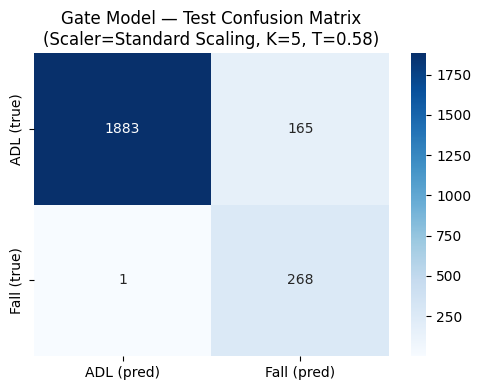

Saved: confusion_matrix_gate_20feat.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

test_probs = final_model.predict_proba(X_test_k)[:, 1]
test_preds = (test_probs >= CHOSEN_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()
test_tpr  = tp / (tp + fn)
test_tnr  = tn / (tn + fp)
test_prec = tp / (tp + fp) if (tp + fp) > 0 else 0
test_f1   = (2 * test_prec * test_tpr) / (test_prec + test_tpr) if (test_prec + test_tpr) > 0 else 0
test_ir   = (tp + fp) / len(y_test)
test_nir  = 1 - test_ir

print("=" * 65)
print(f"FINAL TEST SET RESULTS  (T = {CHOSEN_THRESHOLD})")
print(f"Scaler: {CHOSEN_SCALER}  |  K features: {K_CHOSEN}")
print(f"Features: {chosen_feature_names}")
print("=" * 65)
print(f"Sensitivity (TPR)    : {test_tpr:.4f}")
print(f"Specificity (TNR)    : {test_tnr:.4f}")
print(f"Precision            : {test_prec:.4f}")
print(f"F1 Score             : {test_f1:.4f}")
print(f"Invocation Rate (IR) : {test_ir:.4f}  ({test_ir*100:.1f}% windows → CNN)")
print(f"Non-Invocation Rate  : {test_nir:.4f}  ({test_nir*100:.1f}% CNN executions saved)")
print(f"\nTP={tp}  FN={fn} (missed falls)  TN={tn}  FP={fp} (false alarms)")

# CNN reference values for comparison
print("\n--- COMPARISON WITH CNN BASELINE ---")
print(f"{'Metric':<22} {'Gate (this)':>12} {'CNN baseline':>14}")
print("-" * 50)
print(f"{'Sensitivity (TPR)':<22} {test_tpr:>12.4f} {'0.9740':>14}")
print(f"{'Specificity (TNR)':<22} {test_tnr:>12.4f} {'0.9941':>14}")
print(f"{'Precision':<22} {test_prec:>12.4f} {'0.9562':>14}")
print(f"{'F1 Score':<22} {test_f1:>12.4f} {'0.9650':>14}")
print(f"{'CNN Invocations':<22} {f'{test_ir*100:.1f}%':>12} {'100%':>14}")

cm_plot = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ADL (pred)', 'Fall (pred)'],
            yticklabels=['ADL (true)', 'Fall (true)'])
plt.title(f'Gate Model — Test Confusion Matrix\n(Scaler={CHOSEN_SCALER}, K={K_CHOSEN}, T={CHOSEN_THRESHOLD})')
plt.tight_layout()
plt.savefig("confusion_matrix_gate_20feat.png", dpi=150)
plt.show()
print("Saved: confusion_matrix_gate_20feat.png")

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/sisfall_dataset/lightweight_model"

pd.DataFrame([{
    "Experiment":        "No Scaling + Logistic Regression",   # ← change per file
    "Scaler":            CHOSEN_SCALER,
    "Model":             CHOSEN_MODEL,
    "Features Start":    20,
    "K Selected (RFE)":  K_CHOSEN,
    "Selected Features": ", ".join(chosen_feature_names),
    "Best C":            best_C,
    "Best Penalty":      best_penalty,
    "Threshold":         CHOSEN_THRESHOLD,
    "Test TPR":          round(test_tpr,  4),
    "Test TNR":          round(test_tnr,  4),
    "Test Precision":    round(test_prec, 4),
    "Test F1":           round(test_f1,   4),
    "Test IR":           round(test_ir,   4),
    "Test NIR":          round(test_nir,  4),
    "Missed Falls (FN)": fn,
    "CNN Savings (%)":   round(test_nir * 100, 1)
}]).to_csv(f"{SAVE_DIR}/result_exp1_no_scaling_logreg.csv", index=False)  # ← change per file

print(f"Saved to: {SAVE_DIR}/result_exp3_standard_logreg.csv")

Saved to: /content/drive/MyDrive/sisfall_dataset/lightweight_model/result_exp3_standard_logreg.csv


In [ ]:
print("=== SCALER PARAMETERS ===")
print("means:", sc.mean_.tolist())
print("stds:", sc.scale_.tolist())

print("\n=== GATE MODEL PARAMETERS ===")
print("intercept:", final_model.intercept_.tolist())
print("coefficients:", final_model.coef_.tolist())
print("K chosen:", K_CHOSEN)
print("features:", chosen_feature_names)
print("threshold:", CHOSEN_THRESHOLD)

=== SCALER PARAMETERS ===
means: [0.42971454273754756, -0.2887337536218261, 0.33653926570932496, 0.17680961572224266, 0.27045762159952963, 0.19510111703047683, 0.8927497124657171, 1.2479464799168363, 0.9444061794988057, 0.07834210888735628, 1.574355499439405, 6795.9364123993255, 1.4019766041823933, 58.42353162687036, 1.1817498617464173, 1.921234756391909, 0.4027520253407969, 2.120018342817862, 0.31212664115634287, 22.0291616120648]
stds: [1.0906016746100955, 1.1364981259988605, 0.9329609302951114, 0.3588053383909056, 0.4427257569038268, 0.3272144758746891, 1.9249997433888513, 2.1519916902413607, 1.7374088172676299, 0.1442703293909912, 1.4480788079880127, 17613.298448316054, 0.4145862102413671, 85.03158948616705, 0.4216903653073832, 3.303091607734358, 0.6419352746416279, 2.094810274411141, 0.5143170046182082, 34.58962470467294]

=== GATE MODEL PARAMETERS ===
intercept: [-0.614884350201382]
coefficients: [[1.0181210950729982, 0.32774068140451756, 0.0, 0.05188830974505934, 0.0]]
K chosen:

In [ ]:
# ── Identify zero-coefficient features ──────────────────────────────────────
coefficients = final_model.coef_[0]
coef_df = pd.DataFrame({
    "Feature":     chosen_feature_names,
    "Coefficient": coefficients
})

zero_coef_features = coef_df[coef_df["Coefficient"] == 0.0]["Feature"].tolist()
nonzero_features   = coef_df[coef_df["Coefficient"] != 0.0]["Feature"].tolist()

print("All selected features and their coefficients:")
print(coef_df.to_string(index=False))
print()
print(f"Zero-coefficient features ({len(zero_coef_features)}): {zero_coef_features}")
print(f"Remaining features        ({len(nonzero_features)}): {nonzero_features}")

# ── BEFORE: re-evaluate on test using all K chosen features ─────────────────
test_probs_before = final_model.predict_proba(X_test_k)[:, 1]
test_preds_before = (test_probs_before >= CHOSEN_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_preds_before).ravel()
before = {
    "Features":         K_CHOSEN,
    "TPR (Sensitivity)": tp / (tp + fn),
    "TNR (Specificity)": tn / (tn + fp),
    "Precision":         tp / (tp + fp) if (tp + fp) > 0 else 0,
    "F1 Score":          0,
    "IR":                (tp + fp) / len(y_test),
    "FN (Missed Falls)": fn,
}
before["F1 Score"] = (2 * before["Precision"] * before["TPR (Sensitivity)"]) /                     (before["Precision"] + before["TPR (Sensitivity)"])                     if (before["Precision"] + before["TPR (Sensitivity)"]) > 0 else 0

# ── Build reduced feature matrices ───────────────────────────────────────────
nonzero_indices = [chosen_feature_names.index(f) for f in nonzero_features]
X_train_reduced = X_train_k[:, nonzero_indices]
X_val_reduced   = X_val_k[:,   nonzero_indices]
X_test_reduced  = X_test_k[:,  nonzero_indices]

# ── Retrain on reduced feature set ───────────────────────────────────────────
reduced_model = LogisticRegression(
    C=best_C, penalty=best_penalty,
    solver="liblinear", class_weight="balanced",
    max_iter=5000, random_state=42
)
reduced_model.fit(X_train_reduced, y_train)

# ── AFTER: evaluate on test set ──────────────────────────────────────────────
test_probs_after = reduced_model.predict_proba(X_test_reduced)[:, 1]
test_preds_after = (test_probs_after >= CHOSEN_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_preds_after).ravel()
after = {
    "Features":         len(nonzero_features),
    "TPR (Sensitivity)": tp / (tp + fn),
    "TNR (Specificity)": tn / (tn + fp),
    "Precision":         tp / (tp + fp) if (tp + fp) > 0 else 0,
    "F1 Score":          0,
    "IR":                (tp + fp) / len(y_test),
    "FN (Missed Falls)": fn,
}
after["F1 Score"] = (2 * after["Precision"] * after["TPR (Sensitivity)"]) /                    (after["Precision"] + after["TPR (Sensitivity)"])                    if (after["Precision"] + after["TPR (Sensitivity)"]) > 0 else 0

# ── Print comparison table ───────────────────────────────────────────────────
metrics = ["Features", "TPR (Sensitivity)", "TNR (Specificity)",
           "Precision", "F1 Score", "IR", "FN (Missed Falls)"]

print("\n" + "="*68)
print("BEFORE vs AFTER Dropping Zero-Coefficient Features (Test Set)")
print("="*68)
print(f"{'Metric':<24} {'BEFORE':>12} {'AFTER':>12} {'Delta':>10}")
print("-"*68)
for m in metrics:
    b, a = before[m], after[m]
    if isinstance(b, float):
        delta = a - b
        sign  = "+" if delta >= 0 else ""
        print(f"{m:<24} {b:>12.4f} {a:>12.4f} {sign+f'{delta:.4f}':>10}")
    else:
        print(f"{m:<24} {b:>12} {a:>12} {a-b:>+10}")
print("="*68)

# ── Print new coefficients ───────────────────────────────────────────────────
print("\nReduced model coefficients:")
reduced_coef_df = pd.DataFrame({
    "Feature":     nonzero_features,
    "Coefficient": reduced_model.coef_[0]
})
print(reduced_coef_df.to_string(index=False))
print(f"\nDropped : {zero_coef_features}")
print(f"Kept    : {nonzero_features}")

All selected features and their coefficients:
                   Feature  Coefficient
gyro_signal_magnitude_area     1.018121
               accel_y_max     0.327741
         accel_y_mean_jerk     0.000000
             accel_svm_max     0.051888
               accel_z_std     0.000000

Zero-coefficient features (2): ['accel_y_mean_jerk', 'accel_z_std']
Remaining features        (3): ['gyro_signal_magnitude_area', 'accel_y_max', 'accel_svm_max']

BEFORE vs AFTER Dropping Zero-Coefficient Features (Test Set)
Metric                         BEFORE        AFTER      Delta
--------------------------------------------------------------------
Features                            5            3         -2
TPR (Sensitivity)              0.9963       0.9963    +0.0000
TNR (Specificity)              0.9194       0.9194    +0.0000
Precision                      0.6189       0.6189    +0.0000
F1 Score                       0.7635       0.7635    +0.0000
IR                             0.1869       0.1

In [ ]:
# ── Computation cost analysis ────────────────────────────────────────────────
import time

N_RUNS = 500   # repeat inference to get stable timing

# Time BEFORE (K features)
t0 = time.perf_counter()
for _ in range(N_RUNS):
    _ = final_model.predict_proba(X_test_k)
t_before = (time.perf_counter() - t0) / N_RUNS * 1000   # ms per call

# Time AFTER (K - 2 features)
t0 = time.perf_counter()
for _ in range(N_RUNS):
    _ = reduced_model.predict_proba(X_test_reduced)
t_after = (time.perf_counter() - t0) / N_RUNS * 1000

# Feature-level cost breakdown
n_before    = K_CHOSEN
n_after     = len(nonzero_features)
n_dropped   = len(zero_coef_features)

feat_reduction_pct  = n_dropped / n_before * 100
dot_ops_before      = n_before   # 1 multiply + 1 add per feature = 2 FLOPs, proportional
dot_ops_after       = n_after
flop_reduction_pct  = (dot_ops_before - dot_ops_after) / dot_ops_before * 100

# Memory
bytes_before = n_before * 4   # float32 per feature value (single window)
bytes_after  = n_after  * 4
mem_saved    = bytes_before - bytes_after

timing_delta     = t_before - t_after
timing_delta_pct = timing_delta / t_before * 100 if t_before > 0 else 0

print("\n" + "="*60)
print("COMPUTATION COST ANALYSIS")
print("="*60)
print(f"{'':30} {'BEFORE':>10} {'AFTER':>10} {'SAVED':>8}")
print("-"*60)
print(f"{'# Features':<30} {n_before:>10} {n_after:>10} {n_dropped:>+8}")
print(f"{'Feature reduction':<30} {'':>10} {'':>10} {feat_reduction_pct:>7.1f}%")
print(f"{'Dot-product FLOPs (relative)':<30} {dot_ops_before:>10} {dot_ops_after:>10} {flop_reduction_pct:>7.1f}%")
print(f"{'Feature memory / window (B)':<30} {bytes_before:>10} {bytes_after:>10} {mem_saved:>+8}")
print(f"{'Inference time (ms/batch)':<30} {t_before:>10.4f} {t_after:>10.4f} {timing_delta:>+8.4f}")
print(f"{'Inference speedup':<30} {'':>10} {'':>10} {timing_delta_pct:>7.1f}%")
print("="*60)
print(f"\nNote: Timing averaged over {N_RUNS} runs on the full test set.")
print(f"      On-device cost per single window is proportionally identical.")
print(f"      Dropping {n_dropped} features saves {flop_reduction_pct:.1f}% of the dot-product compute")
print(f"      in the logistic regression step (bias + Σ wᵢxᵢ).")


COMPUTATION COST ANALYSIS
                                   BEFORE      AFTER    SAVED
------------------------------------------------------------
# Features                              5          3       +2
Feature reduction                                       40.0%
Dot-product FLOPs (relative)            5          3    40.0%
Feature memory / window (B)            20         12       +8
Inference time (ms/batch)          0.1961     0.1801  +0.0160
Inference speedup                                        8.2%

Note: Timing averaged over 500 runs on the full test set.
      On-device cost per single window is proportionally identical.
      Dropping 2 features saves 40.0% of the dot-product compute
      in the logistic regression step (bias + Σ wᵢxᵢ).
